 #### Intelligent Dead Reckoning with IO-VNBD
Full ML prototype for SIH 2026 problem 26168 — AI/ML based Intelligent Dead Reckoning for seamless navigation
This notebook trains a lightweight inertial model on synchronized smartphone data from the
IO-VNBD repository, evaluates it on a completely held-out drive,
simulates 10–60 second GNSS outages, plots position drift, demonstrates GNSS/INS fusion, and exports
a deployable prototype artifact.
Prototype claim: this is an evidence-producing baseline and engineering scaffold. It is not yet a
lane-level, safety-certified navigation system. Cross-phone, cross-mount, cross-driver, and longer-outage
validation are required before making that claim.

## What is being predicted?
The phone samples 3-axis acceleration, gravity, angular rate, magnetic field, and orientation at about
10 Hz. We aggregate a three-second causal context (current one-second window plus two lagged windows). The
model predicts change in speed and change in heading, not map-specific coordinates. At an outage
boundary, the last GNSS velocity initializes the state; ML corrections are then integrated into horizontal
displacement. GPS is used only to create training labels and anchors; GPS columns are never model inputs.
Leakage control: route S-Vta1a is the development/training drive and S-Vta2 is held out until the
final evaluation. Adjacent samples from the test drive are never randomly mixed into training.
Pipeline: IO-VNBD CSV → 10 Hz cleaning → 3 s causal context → route split → Ridge/MLP selection → speed/heading recursion → GNSS fusion → edge artifact.

In [5]:
from __future__ import annotations

import json
import math
import platform
import urllib.request
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "data").exists() else cwd / "outputs" if (cwd / "outputs" / "data").exists() else cwd
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
FIGURE_DIR = ROOT / "figures"
for directory in (DATA_DIR, ARTIFACT_DIR, FIGURE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "root": str(ROOT),
})


{'python': '3.14.3', 'numpy': '2.4.3', 'pandas': '3.0.2', 'scikit_learn': '1.9.0', 'root': 'E:\\Intelligent-Dead-Reckoning-with-IO-VNBD'}


## 1. Acquire a reproducible IO-VNBD subset
The two source files are stored with Git LFS. Local copies are bundled beside this notebook. If they are
missing, the cell downloads the exact upstream files from GitHub's media endpoint. S-Vta1a is used for
development and training; S-Vta2 is the independent test route.

In [6]:
ROUTES = {
    "S-Vta1a": {
        "role": "train",
        "file": "S-Vta1a.csv",
        "url": "https://media.githubusercontent.com/media/onyekpeu/IO-VNBD/master/Synchronised%20V%20abd%20S%20datasets/Categorised%20IOVNB%20Dataset/Vta%20%28Driver%20E%29/Vta01a/S-Vta1a.csv",
    },
    "S-Vta2": {
        "role": "test",
        "file": "S-Vta2.csv",
        "url": "https://media.githubusercontent.com/media/onyekpeu/IO-VNBD/master/Synchronised%20V%20abd%20S%20datasets/Categorised%20IOVNB%20Dataset/Vta%20%28Driver%20E%29/Vta02/S-Vta2.csv",
    },
}

for route_id, spec in ROUTES.items():
    destination = DATA_DIR / spec["file"]
    if not destination.exists() or destination.stat().st_size < 1_000:
        print(f"Downloading {route_id} …")
        urllib.request.urlretrieve(spec["url"], destination)
    print(f"{route_id:8s} | {spec['role']:5s} | {destination.stat().st_size / 1e6:6.2f} MB")


S-Vta1a  | train |   4.77 MB
S-Vta2   | test  |   2.04 MB


## 2. Load and standardize the smartphone schema
IO-VNBD's CSV header contains unit symbols whose rendering depends on local encoding. The repository's
documented 24-column order is therefore mapped to stable names. Satellite-count text and timestamps are
preserved, while sensor and positioning values are coerced to numeric types.

In [7]:
SCHEMA = [
    "lat", "lon", "alt_m", "gps_speed", "gps_accuracy_m", "gps_orientation_deg",
    "satellites", "t_ms", "timestamp", "ax", "ay", "az", "gravity_x", "gravity_y",
    "gravity_z", "gyro_yaw", "gyro_pitch", "gyro_roll", "mag_x", "mag_y", "mag_z",
    "yaw_deg", "pitch_deg", "roll_deg",
]
NUMERIC = [c for c in SCHEMA if c not in {"satellites", "timestamp"}]
EARTH_RADIUS_M = 6_371_000.0

def load_route(path: Path, route_id: str) -> pd.DataFrame:
    frame = pd.read_csv(path, encoding_errors="replace")
    if frame.shape[1] != len(SCHEMA):
        raise ValueError(f"Expected {len(SCHEMA)} columns, found {frame.shape[1]} in {path.name}")
    frame.columns = SCHEMA
    for column in NUMERIC:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame = frame.dropna(subset=["t_ms", "lat", "lon"]).sort_values("t_ms").drop_duplicates("t_ms")
    frame = frame[(frame["lat"].abs() <= 90) & (frame["lon"].abs() <= 180)].copy()
    frame["route_id"] = route_id
    frame["elapsed_s"] = (frame["t_ms"] - frame["t_ms"].iloc[0]) / 1000.0
    return frame.reset_index(drop=True)

raw_routes = {
    route_id: load_route(DATA_DIR / spec["file"], route_id)
    for route_id, spec in ROUTES.items()
}

audit_rows = []
for route_id, frame in raw_routes.items():
    gps_unique = frame[["lat", "lon"]].drop_duplicates().shape[0]
    audit_rows.append({
        "route": route_id,
        "role": ROUTES[route_id]["role"],
        "raw_rows": len(frame),
        "duration_min": frame["elapsed_s"].iloc[-1] / 60,
        "median_hz": 1 / frame["elapsed_s"].diff().median(),
        "unique_gps_fixes": gps_unique,
        "median_gps_accuracy_m": frame["gps_accuracy_m"].median(),
    })
audit = pd.DataFrame(audit_rows).set_index("route")
display(audit.round(2))


,role,raw_rows,duration_min,median_hz,unique_gps_fixes,median_gps_accuracy_m
route,,,,,,
S-Vta1a,train,25676,42.79,10.0,2519,4.0
S-Vta2,test,10991,18.32,10.0,1023,4.0


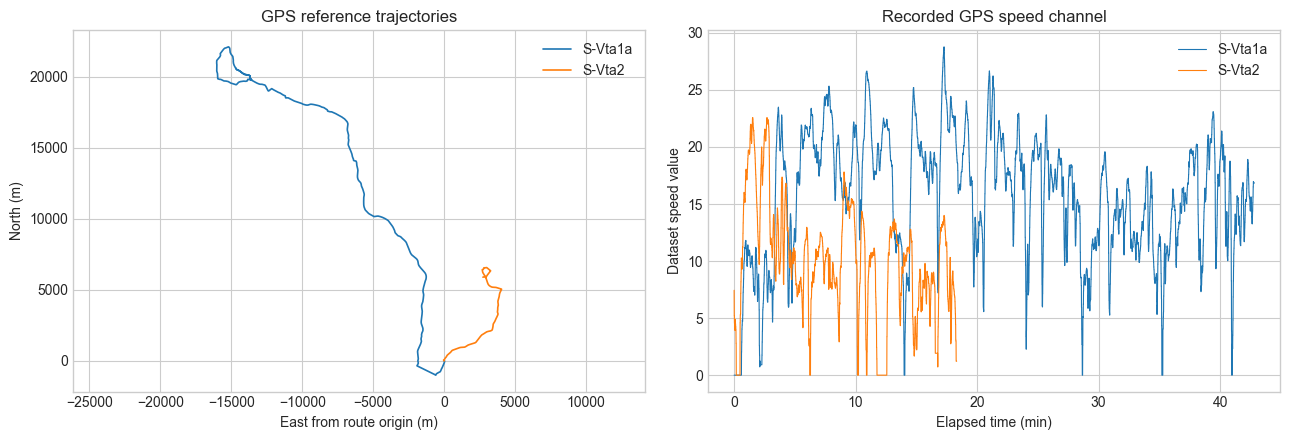

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for route_id, frame in raw_routes.items():
    lat0, lon0 = frame[["lat", "lon"]].iloc[0]
    east = np.deg2rad(frame["lon"] - lon0) * EARTH_RADIUS_M * np.cos(np.deg2rad(lat0))
    north = np.deg2rad(frame["lat"] - lat0) * EARTH_RADIUS_M
    axes[0].plot(east, north, lw=1.2, label=route_id)
    axes[1].plot(frame["elapsed_s"] / 60, frame["gps_speed"], lw=0.8, label=route_id)
axes[0].set(title="GPS reference trajectories", xlabel="East from route origin (m)", ylabel="North (m)")
axes[0].axis("equal")
axes[1].set(title="Recorded GPS speed channel", xlabel="Elapsed time (min)", ylabel="Dataset speed value")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_route_audit.png", dpi=160, bbox_inches="tight")
plt.show()


## 3. Causal inertial features and route-invariant state targets
Each base feature row uses sensor samples from one elapsed second. Circular orientation channels are encoded
as sine/cosine; unwrapped within-window angle change is added explicitly. Two lagged feature rows provide
three seconds of causal context. GPS latitude, longitude, speed, accuracy, and GPS orientation are excluded
from the feature list.
The target is (change in speed, change in heading). This avoids teaching the network a route-specific map
direction. At inference, the state is initialized from the last GNSS displacement and updated recursively.
A 45 m/s displacement sanity limit rejects isolated GPS jumps from supervised training and outage scoring;
rows are retained so temporal continuity can still be audited.

In [9]:
BASE_SENSOR_COLUMNS = [
    "ax", "ay", "az", "gravity_x", "gravity_y", "gravity_z",
    "gyro_yaw", "gyro_pitch", "gyro_roll", "mag_x", "mag_y", "mag_z",
]
CIRCULAR_COLUMNS = ["yaw_deg", "pitch_deg", "roll_deg"]
STATS = ["mean", "std", "min", "max", "last"]
MAX_PLAUSIBLE_STEP_M = 45.0

def build_second_features(raw: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    frame = raw.copy()
    frame["sec"] = np.floor(frame["elapsed_s"]).astype(int)
    for angle in CIRCULAR_COLUMNS:
        radians = np.deg2rad(frame[angle])
        frame[f"{angle}_sin"] = np.sin(radians)
        frame[f"{angle}_cos"] = np.cos(radians)
        frame[f"{angle}_unwrapped"] = np.unwrap(radians.ffill().fillna(0.0))

    sensor_columns = BASE_SENSOR_COLUMNS + [
        f"{angle}_{component}" for angle in CIRCULAR_COLUMNS for component in ("sin", "cos")
    ]
    grouped = frame.groupby("sec", sort=True)
    features = grouped[sensor_columns].agg(STATS)
    features.columns = [f"{sensor}__{stat}" for sensor, stat in features.columns]
    for angle in CIRCULAR_COLUMNS:
        features[f"{angle}__change"] = (
            grouped[f"{angle}_unwrapped"].last() - grouped[f"{angle}_unwrapped"].first()
        )
    base_feature_names = features.columns.tolist()
    features = features.replace([np.inf, -np.inf], np.nan)

    position = grouped[["lat", "lon", "gps_accuracy_m"]].median()
    lat0, lon0 = position[["lat", "lon"]].iloc[0]
    position["east_m"] = np.deg2rad(position["lon"] - lon0) * EARTH_RADIUS_M * np.cos(np.deg2rad(lat0))
    position["north_m"] = np.deg2rad(position["lat"] - lat0) * EARTH_RADIUS_M

    result = features.join(position)
    result["target_east_m"] = result["east_m"].shift(-1) - result["east_m"]
    result["target_north_m"] = result["north_m"].shift(-1) - result["north_m"]
    result["step_distance_m"] = np.hypot(result["target_east_m"], result["target_north_m"])
    result["step_heading_rad"] = np.arctan2(result["target_north_m"], result["target_east_m"])
    result["previous_speed_mps"] = result["step_distance_m"].shift(1)
    result["previous_heading_rad"] = result["step_heading_rad"].shift(1)
    result["target_delta_speed_mps"] = result["step_distance_m"] - result["previous_speed_mps"]
    heading_difference = result["step_heading_rad"] - result["previous_heading_rad"]
    result["target_turn_rad"] = np.arctan2(np.sin(heading_difference), np.cos(heading_difference))
    # Heading is undefined when stationary; use zero turn so stops do not inject arbitrary angle labels.
    stopped = (result["step_distance_m"] < 1.0) | (result["previous_speed_mps"] < 1.0)
    result.loc[stopped, "target_turn_rad"] = 0.0
    next_sec = result.index.to_series().shift(-1)
    result["valid_target"] = (
        (next_sec - result.index.to_series() == 1)
        & result["step_distance_m"].notna()
        & result["previous_speed_mps"].notna()
        & (result["step_distance_m"] <= MAX_PLAUSIBLE_STEP_M)
        & (result["previous_speed_mps"] <= MAX_PLAUSIBLE_STEP_M)
    )
    result["route_id"] = raw["route_id"].iloc[0]
    result[base_feature_names] = result[base_feature_names].interpolate(limit_direction="both").fillna(0.0)
    lag_blocks = []
    for lag in (1, 2):
        lagged = result[base_feature_names].shift(lag).add_suffix(f"__lag{lag}")
        lag_blocks.append(lagged)
    result = pd.concat([result, *lag_blocks], axis=1)
    feature_names = base_feature_names + [column for block in lag_blocks for column in block.columns]
    result[feature_names] = result[feature_names].interpolate(limit_direction="both").fillna(0.0)
    return result.reset_index(), feature_names

second_routes = {}
for route_id, raw in raw_routes.items():
    second_routes[route_id], feature_names = build_second_features(raw)

feature_audit = pd.DataFrame([
    {
        "route": route_id,
        "one_second_rows": len(frame),
        "valid_label_rows": int(frame["valid_target"].sum()),
        "rejected_or_last_rows": int((~frame["valid_target"]).sum()),
    }
    for route_id, frame in second_routes.items()
]).set_index("route")
print(f"Model input features: {len(feature_names)} (GPS-derived inputs: 0)")
display(feature_audit)


Model input features: 279 (GPS-derived inputs: 0)


C:\Users\Suman Patari\AppData\Local\Temp\ipykernel_7856\4196255348.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  return result.reset_index(), feature_names
C:\Users\Suman Patari\AppData\Local\Temp\ipykernel_7856\4196255348.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  return result.reset_index(), feature_names


,one_second_rows,valid_label_rows,rejected_or_last_rows
route,,,
S-Vta1a,2568,2566,2
S-Vta2,1099,1097,2


## 4. Route-aware model selection and final training
The last 20% of the training route is a chronological validation block. It selects between a regularized
linear model and a compact two-hidden-layer MLP. The selected architecture is then refit on all valid rows
of S-Vta1a and evaluated exactly once on S-Vta2.

In [10]:
train_frame = second_routes["S-Vta1a"]
test_frame = second_routes["S-Vta2"]
target_names = ["target_delta_speed_mps", "target_turn_rad"]
step_target_names = ["target_east_m", "target_north_m"]

valid_train = train_frame[train_frame["valid_target"]].copy()
split_at = int(len(valid_train) * 0.80)
development = valid_train.iloc[:split_at]
validation = valid_train.iloc[split_at:]

candidates = {
    "Ridge": Pipeline([
        ("scale", StandardScaler()),
        ("regressor", Ridge(alpha=20.0)),
    ]),
    "Compact MLP": TransformedTargetRegressor(
        regressor=Pipeline([
            ("scale", StandardScaler()),
            ("regressor", MLPRegressor(
                hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                alpha=2e-3, batch_size=128, learning_rate_init=1e-3,
                max_iter=300, early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=18, random_state=SEED,
            )),
        ]),
        transformer=StandardScaler(),
    ),
}

def displacement_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    errors = y_pred - y_true
    distances = np.linalg.norm(errors, axis=1)
    return {
        "vector_MAE_m": float(distances.mean()),
        "vector_RMSE_m": float(np.sqrt(np.mean(np.sum(errors ** 2, axis=1)))),
        "east_R2": float(r2_score(y_true[:, 0], y_pred[:, 0])),
        "north_R2": float(r2_score(y_true[:, 1], y_pred[:, 1])),
    }

selection_rows = []
for name, candidate in candidates.items():
    fitted = clone(candidate).fit(development[feature_names], development[target_names])
    prediction = fitted.predict(validation[feature_names])
    truth = validation[target_names].to_numpy()
    speed_rmse = float(mean_squared_error(truth[:, 0], prediction[:, 0]) ** 0.5)
    turn_rmse = float(mean_squared_error(truth[:, 1], prediction[:, 1]) ** 0.5)
    selection_rows.append({
        "model": name,
        "delta_speed_RMSE_mps": speed_rmse,
        "turn_RMSE_deg": np.rad2deg(turn_rmse),
        "selection_score": speed_rmse + 5.0 * turn_rmse,
    })
selection = pd.DataFrame(selection_rows).sort_values("selection_score").reset_index(drop=True)
display(selection.round(3))

selected_name = selection.loc[0, "model"]
final_model = clone(candidates[selected_name]).fit(valid_train[feature_names], valid_train[target_names])
print(f"Selected from chronological validation: {selected_name}")


,model,delta_speed_RMSE_mps,turn_RMSE_deg,selection_score
0,Ridge,1.081,6.216,1.624
1,Compact MLP,1.214,7.682,1.885


Selected from chronological validation: Ridge


## 5. Held-out one-second displacement evaluation
Zero motion is a simple sanity baseline. Previous displacement is an optimistic one-step persistence
reference because it assumes the last true step is available; it is not used during multi-second
blackouts. The honest outage baseline below freezes only the velocity known at the outage boundary.

In [11]:
def clip_state_corrections(prediction: np.ndarray) -> np.ndarray:
    clipped = np.asarray(prediction, dtype=float).copy()
    clipped[:, 0] = np.clip(clipped[:, 0], -8.0, 8.0)       # m/s change per second
    clipped[:, 1] = np.clip(clipped[:, 1], -0.8, 0.8)       # rad heading change per second
    return clipped

def corrections_to_one_step(frame: pd.DataFrame, corrections: np.ndarray) -> np.ndarray:
    speed = np.clip(frame["previous_speed_mps"].to_numpy() + corrections[:, 0], 0.0, MAX_PLAUSIBLE_STEP_M)
    heading = frame["previous_heading_rad"].to_numpy() + corrections[:, 1]
    return np.column_stack([speed * np.cos(heading), speed * np.sin(heading)])

all_state_prediction = clip_state_corrections(final_model.predict(test_frame[feature_names]))
all_model_steps = corrections_to_one_step(test_frame, all_state_prediction)
test_mask = test_frame["valid_target"].to_numpy()
y_test = test_frame.loc[test_mask, step_target_names].to_numpy()
model_test = all_model_steps[test_mask]

previous_speed = test_frame["previous_speed_mps"].fillna(0.0).to_numpy()
previous_heading = test_frame["previous_heading_rad"].fillna(0.0).to_numpy()
previous = np.column_stack([
    previous_speed * np.cos(previous_heading), previous_speed * np.sin(previous_heading)
])[test_mask]
baselines = {
    "Zero motion": np.zeros_like(y_test),
    "Previous displacement (one-step oracle)": previous,
    selected_name: model_test,
}
heldout_rows = [{"method": name, **displacement_metrics(y_test, prediction)} for name, prediction in baselines.items()]
heldout_metrics = pd.DataFrame(heldout_rows).sort_values("vector_RMSE_m").reset_index(drop=True)
display(heldout_metrics.round(3))
heldout_metrics.to_csv(ARTIFACT_DIR / "heldout_one_second_metrics.csv", index=False)


,method,vector_MAE_m,vector_RMSE_m,east_R2,north_R2
0,Ridge,0.748,1.022,0.994,0.981
1,Previous displacement (one-step oracle),0.861,1.188,0.990,0.977
2,Zero motion,10.064,11.304,-0.110,-0.793


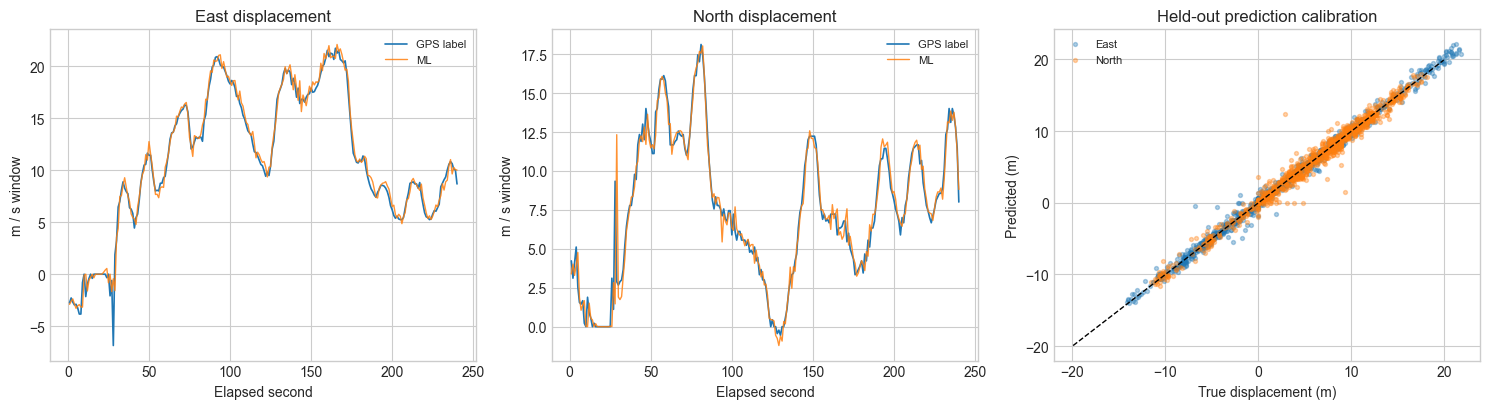

In [12]:
valid_indices = np.flatnonzero(test_mask)
show = valid_indices[: min(240, len(valid_indices))]
truth_show = test_frame.loc[show, step_target_names].to_numpy()
pred_show = all_model_steps[show]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(test_frame.loc[show, "sec"], truth_show[:, 0], label="GPS label", lw=1.2)
axes[0].plot(test_frame.loc[show, "sec"], pred_show[:, 0], label="ML", lw=1.0, alpha=0.85)
axes[0].set(title="East displacement", xlabel="Elapsed second", ylabel="m / s window")
axes[1].plot(test_frame.loc[show, "sec"], truth_show[:, 1], label="GPS label", lw=1.2)
axes[1].plot(test_frame.loc[show, "sec"], pred_show[:, 1], label="ML", lw=1.0, alpha=0.85)
axes[1].set(title="North displacement", xlabel="Elapsed second", ylabel="m / s window")
axes[2].scatter(y_test[:, 0], model_test[:, 0], s=8, alpha=0.35, label="East")
axes[2].scatter(y_test[:, 1], model_test[:, 1], s=8, alpha=0.35, label="North")
limit = np.nanpercentile(np.abs(y_test), 99)
axes[2].plot([-limit, limit], [-limit, limit], "k--", lw=1)
axes[2].set(title="Held-out prediction calibration", xlabel="True displacement (m)", ylabel="Predicted (m)")
for ax in axes:
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_one_second_predictions.png", dpi=160, bbox_inches="tight")
plt.show()


## 6. Simulated GNSS blackouts
For each eligible window, the last five pre-outage GPS displacements estimate the constant-velocity
baseline. The model receives only inertial/orientation features during the outage. Both paths start at the
same final GNSS fix, and no later GPS sample is used until evaluation.

In [13]:
test_truth_steps = test_frame[step_target_names].to_numpy()

def eligible_starts(frame: pd.DataFrame, duration_s: int, stride: int = 45, history: int = 5) -> list[int]:
    starts = []
    for start in range(history, len(frame) - duration_s - 1, stride):
        segment = frame.iloc[start : start + duration_s]
        history_segment = frame.iloc[start - history : start]
        if (
            segment["valid_target"].all()
            and history_segment["valid_target"].all()
            and np.all(np.diff(segment["sec"].to_numpy()) == 1)
        ):
            starts.append(start)
    return starts

def simulate_window(start: int, duration_s: int) -> dict[str, np.ndarray]:
    truth_steps = test_truth_steps[start : start + duration_s]
    corrections = all_state_prediction[start : start + duration_s]
    speed = float(test_frame.iloc[start]["previous_speed_mps"])
    heading = float(test_frame.iloc[start]["previous_heading_rad"])
    model_steps = []
    for delta_speed, delta_heading in corrections:
        speed = float(np.clip(speed + delta_speed, 0.0, MAX_PLAUSIBLE_STEP_M))
        heading += float(delta_heading)
        model_steps.append([speed * np.cos(heading), speed * np.sin(heading)])
    model_steps = np.asarray(model_steps)
    initial_velocity = test_truth_steps[start - 5 : start].mean(axis=0)
    baseline_steps = np.repeat(initial_velocity[None, :], duration_s, axis=0)
    return {
        "truth": np.vstack([np.zeros(2), np.cumsum(truth_steps, axis=0)]),
        "model": np.vstack([np.zeros(2), np.cumsum(model_steps, axis=0)]),
        "constant_velocity": np.vstack([np.zeros(2), np.cumsum(baseline_steps, axis=0)]),
    }

outage_rows = []
for duration in (10, 30, 60):
    starts = eligible_starts(test_frame, duration, stride=max(30, duration))
    for start in starts:
        paths = simulate_window(start, duration)
        for method in ("model", "constant_velocity"):
            error = np.linalg.norm(paths[method] - paths["truth"], axis=1)
            outage_rows.append({
                "duration_s": duration,
                "start_s": int(test_frame.iloc[start]["sec"]),
                "method": selected_name if method == "model" else "Frozen constant velocity",
                "endpoint_error_m": float(error[-1]),
                "trajectory_RMSE_m": float(np.sqrt(np.mean(error ** 2))),
            })

outage_results = pd.DataFrame(outage_rows)
outage_summary = (
    outage_results.groupby(["duration_s", "method"])
    .agg(windows=("endpoint_error_m", "size"), median_endpoint_error_m=("endpoint_error_m", "median"),
         p90_endpoint_error_m=("endpoint_error_m", lambda x: x.quantile(0.90)),
         median_trajectory_RMSE_m=("trajectory_RMSE_m", "median"))
    .reset_index()
)
display(outage_summary.round(2))
outage_results.to_csv(ARTIFACT_DIR / "blackout_window_results.csv", index=False)
outage_summary.to_csv(ARTIFACT_DIR / "blackout_summary.csv", index=False)


,duration_s,method,windows,median_endpoint_error_m,p90_endpoint_error_m,median_trajectory_RMSE_m
0,10,Frozen constant velocity,36,26.02,65.03,13.66
1,10,Ridge,36,14.40,28.27,7.24
2,30,Frozen constant velocity,35,119.22,264.71,63.42
3,30,Ridge,35,91.48,170.57,40.20
4,60,Frozen constant velocity,17,295.35,448.46,135.75
5,60,Ridge,17,256.41,579.43,122.71


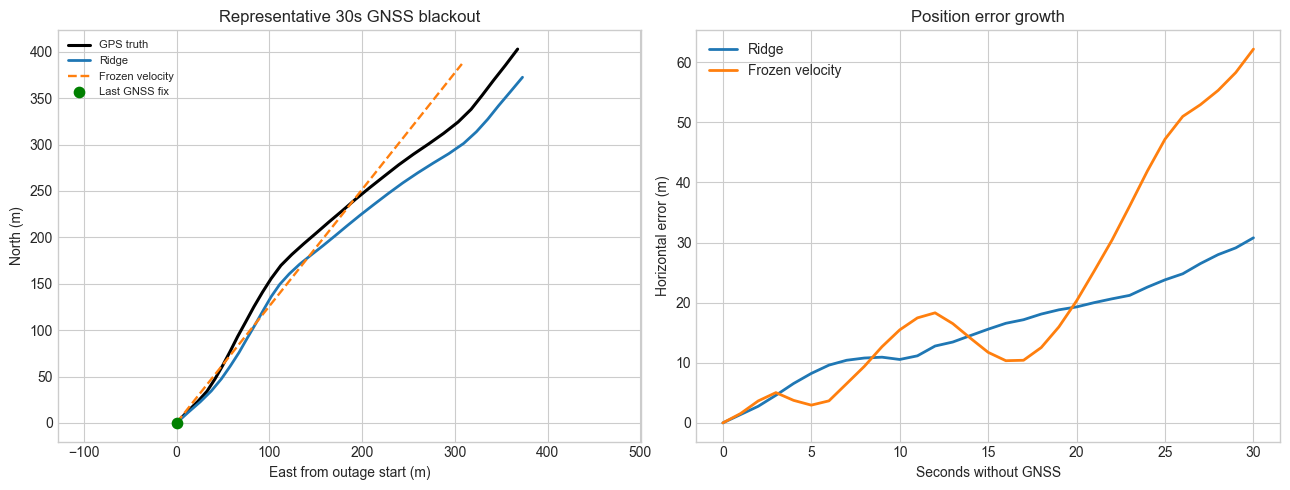

In [14]:
duration = 30
starts = eligible_starts(test_frame, duration, stride=15)
if not starts:
    raise RuntimeError("No continuous held-out window was available for the showcase plot.")

# Choose a segment near the median paired improvement—not a cherry-picked best case.
ranked = []
for start in starts:
    paths = simulate_window(start, duration)
    model_error = np.linalg.norm(paths["model"][-1] - paths["truth"][-1])
    baseline_error = np.linalg.norm(paths["constant_velocity"][-1] - paths["truth"][-1])
    ranked.append((baseline_error - model_error, start))
showcase_start = sorted(ranked)[len(ranked) // 2][1]
showcase = simulate_window(showcase_start, duration)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(showcase["truth"][:, 0], showcase["truth"][:, 1], "k-", lw=2.2, label="GPS truth")
axes[0].plot(showcase["model"][:, 0], showcase["model"][:, 1], lw=2, label=selected_name)
axes[0].plot(showcase["constant_velocity"][:, 0], showcase["constant_velocity"][:, 1], "--", lw=1.7, label="Frozen velocity")
axes[0].scatter([0], [0], c="green", s=55, marker="o", label="Last GNSS fix", zorder=5)
axes[0].set(title=f"Representative {duration}s GNSS blackout", xlabel="East from outage start (m)", ylabel="North (m)")
axes[0].axis("equal")
axes[0].legend(fontsize=8)

for method, label in (("model", selected_name), ("constant_velocity", "Frozen velocity")):
    error = np.linalg.norm(showcase[method] - showcase["truth"], axis=1)
    axes[1].plot(np.arange(duration + 1), error, lw=2, label=label)
axes[1].set(title="Position error growth", xlabel="Seconds without GNSS", ylabel="Horizontal error (m)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_blackout_position_plot.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Hybrid GNSS/INS state machine
The deployment engine should not merely switch sources. At 1 Hz it predicts speed and heading corrections;
when a trustworthy GNSS fix exists, it softly corrects position and re-anchors velocity. During a blackout,
it propagates the state recursively. The compact class below demonstrates the fusion behavior in local
east/north coordinates.

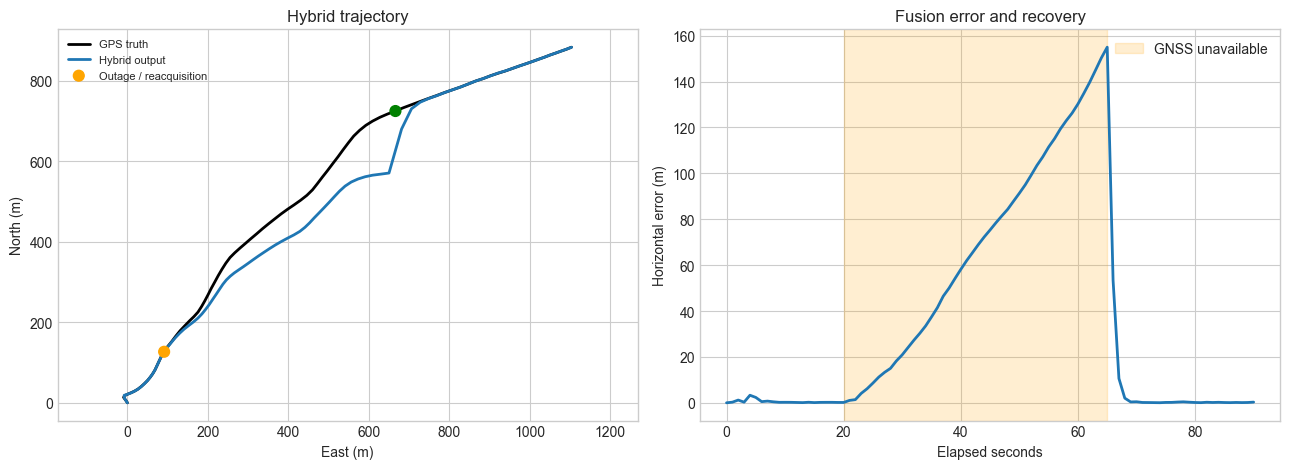

In [15]:
class HybridDeadReckoningEngine:
    def __init__(self, model, feature_names, correction_gain: float = 0.8):
        self.model = model
        self.feature_names = feature_names
        self.correction_gain = correction_gain
        self.position = np.zeros(2, dtype=float)
        self.speed = 0.0
        self.heading = 0.0

    def reset(self, anchor_east_north=(0.0, 0.0), initial_velocity=(0.0, 0.0)):
        self.position = np.asarray(anchor_east_north, dtype=float).copy()
        velocity = np.asarray(initial_velocity, dtype=float)
        self.speed = float(np.linalg.norm(velocity))
        self.heading = float(np.arctan2(velocity[1], velocity[0])) if self.speed > 0.1 else 0.0

    def step(self, feature_row: pd.DataFrame, gnss_position=None, gnss_velocity=None, gnss_accuracy_m=None):
        delta_speed, delta_heading = clip_state_corrections(
            self.model.predict(feature_row[self.feature_names])
        )[0]
        self.speed = float(np.clip(self.speed + delta_speed, 0.0, MAX_PLAUSIBLE_STEP_M))
        self.heading += float(delta_heading)
        increment = self.speed * np.array([np.cos(self.heading), np.sin(self.heading)])
        predicted = self.position + increment
        mode = "INS/ML"
        if gnss_position is not None:
            accuracy = 5.0 if gnss_accuracy_m is None or not np.isfinite(gnss_accuracy_m) else max(float(gnss_accuracy_m), 1.0)
            adaptive_gain = np.clip(self.correction_gain * 5.0 / accuracy, 0.15, self.correction_gain)
            predicted = (1 - adaptive_gain) * predicted + adaptive_gain * np.asarray(gnss_position)
            mode = "GNSS-aided"
            if gnss_velocity is not None:
                velocity = np.asarray(gnss_velocity, dtype=float)
                self.speed = float(np.linalg.norm(velocity))
                if self.speed > 0.1:
                    self.heading = float(np.arctan2(velocity[1], velocity[0]))
        self.position = predicted
        return predicted.copy(), mode

demo_duration = 90
demo_start = eligible_starts(test_frame, demo_duration, stride=20)[0]
blackout_from, blackout_to = 20, 65
demo = test_frame.iloc[demo_start : demo_start + demo_duration].copy()
truth_steps = test_truth_steps[demo_start : demo_start + demo_duration]
truth_positions = np.vstack([np.zeros(2), np.cumsum(truth_steps, axis=0)])

engine = HybridDeadReckoningEngine(final_model, feature_names)
engine.reset((0.0, 0.0), test_truth_steps[demo_start - 1])
hybrid_positions = [engine.position.copy()]
modes = []
for i in range(demo_duration):
    gnss_available = not (blackout_from <= i < blackout_to)
    gnss_position = truth_positions[i + 1] if gnss_available else None
    gnss_velocity = truth_steps[i] if gnss_available else None
    accuracy = demo.iloc[i]["gps_accuracy_m"] if gnss_available else None
    position, mode = engine.step(demo.iloc[[i]], gnss_position, gnss_velocity, accuracy)
    hybrid_positions.append(position)
    modes.append(mode)
hybrid_positions = np.asarray(hybrid_positions)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(truth_positions[:, 0], truth_positions[:, 1], "k-", lw=2, label="GPS truth")
axes[0].plot(hybrid_positions[:, 0], hybrid_positions[:, 1], lw=2, label="Hybrid output")
axes[0].scatter(truth_positions[[blackout_from, blackout_to], 0], truth_positions[[blackout_from, blackout_to], 1],
                c=["orange", "green"], s=60, zorder=5, label="Outage / reacquisition")
axes[0].set(title="Hybrid trajectory", xlabel="East (m)", ylabel="North (m)")
axes[0].axis("equal")
axes[0].legend(fontsize=8)
hybrid_error = np.linalg.norm(hybrid_positions - truth_positions, axis=1)
axes[1].plot(hybrid_error, lw=2)
axes[1].axvspan(blackout_from, blackout_to, color="orange", alpha=0.18, label="GNSS unavailable")
axes[1].set(title="Fusion error and recovery", xlabel="Elapsed seconds", ylabel="Horizontal error (m)")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_hybrid_fusion.png", dpi=180, bbox_inches="tight")
plt.show()


## 8. Export the prototype
The artifact contains the fitted preprocessing/model pipeline, the exact ordered feature contract, schema,
sampling assumptions, source routes, and safety bounds. A production mobile build can convert the selected
pipeline to ONNX/TFLite after installing the relevant exporter, then quantize and benchmark it on target phones.

In [16]:
model_path = ARTIFACT_DIR / "io_vnbd_dead_reckoning_model.joblib"
metadata_path = ARTIFACT_DIR / "model_metadata.json"

joblib.dump(final_model, model_path)
metadata = {
    "problem_statement": "SIH 2026 / 26168",
    "dataset": "IO-VNBD",
    "dataset_repository": "https://github.com/onyekpeu/IO-VNBD",
    "train_route": "S-Vta1a",
    "heldout_test_route": "S-Vta2",
    "selected_model": selected_name,
    "base_window_seconds": 1,
    "causal_context_seconds": 3,
    "nominal_sensor_rate_hz": 10,
    "targets": target_names,
    "feature_names": feature_names,
    "gps_features_used_by_model": [],
    "max_predicted_step_m": MAX_PLAUSIBLE_STEP_M,
    "heldout_metrics": heldout_metrics.to_dict(orient="records"),
    "limitations": [
        "Prototype evaluated on two routes from one public dataset",
        "No phone-remount or cross-device calibration study",
        "GPS fixes are labels and can contain noise or held values",
        "Not safety-certified and not evidence of lane-level accuracy",
    ],
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved model:    {model_path} ({model_path.stat().st_size / 1e6:.2f} MB)")
print(f"Saved metadata: {metadata_path}")


Saved model:    E:\Intelligent-Dead-Reckoning-with-IO-VNBD\artifacts\io_vnbd_dead_reckoning_model.joblib (0.02 MB)
Saved metadata: E:\Intelligent-Dead-Reckoning-with-IO-VNBD\artifacts\model_metadata.json
